# IMPOTAÇÃO DOS DADOS

In [264]:
import kagglehub
import os
import pandas as pd

# 1. Baixar o dataset (isso retorna o caminho da pasta)
path = kagglehub.dataset_download("canozensoy/industrial-iot-dataset-synthetic")

# 2. Listar os arquivos para ver o nome real
files = os.listdir(path)
print(f"Arquivos encontrados: {files}")

# 3. Carregar o primeiro arquivo CSV encontrado
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)


# 4. Visualizar os dados e o Target
display(df.head())

Using Colab cache for faster access to the 'industrial-iot-dataset-synthetic' dataset.
Arquivos encontrados: ['factory_sensor_simulator_2040.csv']


,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


In [265]:
df['AI_Supervision'].describe()

,AI_Supervision
count,500000
unique,2
top,False
freq,349585


# PRÉ-PROCESSAMENTOS DOS DADOS

In [266]:
df.isnull().sum()

,0
Machine_ID,0
Machine_Type,0
Installation_Year,0
Operational_Hours,0
Temperature_C,0
Vibration_mms,0
Sound_dB,0
Oil_Level_pct,0
Coolant_Level_pct,0
Power_Consumption_kW,0


In [267]:
import pandas as pd
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder

# 1. Filtro e Remoção de Colunas
colunas_para_remover = ['Remaining_Useful_Life_days', 'Machine_ID']
df = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

# 2. Limpeza: Valores vazios se tornam 0
df = df.fillna(0)

# 3. Codificação: Transforma categorias (texto) em números
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# 4. Balanceamento Exato (30k True e 30k False)
# Separando as classes
df_true = df[df['Failure_Within_7_Days'] == True]
df_false = df[df['Failure_Within_7_Days'] == False]

# Ajustando a classe TRUE para 30.000 (usando replace=True caso tenha menos que 30k)
df_true_resampled = resample(df_true,
                             replace=len(df_true) < 30000,
                             n_samples=30000,
                             random_state=42)

# Ajustando a classe FALSE para 30.000
df_false_resampled = resample(df_false,
                              replace=len(df_false) < 30000,
                              n_samples=30000,
                              random_state=42)

# Juntando e embaralhando
df_balanced = pd.concat([df_true_resampled, df_false_resampled])
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

# --- Relatório Final ---
print(20*"***")
print("Colunas que ficaram (Sensores Reais):", df_balanced.columns.tolist())
print(20*"***")
print(f"""Ações concluídas com sucesso:
1. Células vazias preenchidas com 0.
2. Balanceamento: {df_balanced['Failure_Within_7_Days'].value_counts()[True]} True e {df_balanced['Failure_Within_7_Days'].value_counts()[False]} False.
3. Total de dados para IA: {len(df_balanced)} linhas.
4. Colunas '{', '.join(colunas_para_remover)}' foram removidas.
""")

************************************************************
Colunas que ficaram (Sensores Reais): ['Machine_Type', 'Installation_Year', 'Operational_Hours', 'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct', 'Coolant_Level_pct', 'Power_Consumption_kW', 'Last_Maintenance_Days_Ago', 'Maintenance_History_Count', 'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days', 'Failure_Within_7_Days', 'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index', 'AI_Override_Events']
************************************************************
Ações concluídas com sucesso: 
1. Células vazias preenchidas com 0.
2. Balanceamento: 30000 True e 30000 False.
3. Total de dados para IA: 60000 linhas.
4. Colunas 'Remaining_Useful_Life_days, Machine_ID' foram removidas.



In [268]:
df_balanced.head(5)

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,4,2018,52182,60.17,6.71,85.35,55.41,74.69,210.08,175,7,4,False,1,False,0.0,0.0,0.0,0.00,0
1,1,2014,94586,82.67,3.59,62.23,59.51,47.15,98.27,279,5,2,False,2,True,0.0,0.0,0.0,0.00,0
2,8,2006,96404,82.76,11.88,92.18,68.01,73.56,22.05,141,5,2,False,1,True,0.0,0.0,0.0,0.00,0
3,31,2005,99412,61.85,10.20,98.53,100.00,80.74,216.84,316,5,2,False,4,True,0.0,0.0,0.0,0.00,0
4,15,2030,13604,95.13,4.79,75.56,53.97,50.10,162.77,318,5,2,True,3,False,0.0,0.0,0.0,446.46,2


In [269]:
df_balanced.isnull().sum()

,0
Machine_Type,0
Installation_Year,0
Operational_Hours,0
Temperature_C,0
Vibration_mms,0
Sound_dB,0
Oil_Level_pct,0
Coolant_Level_pct,0
Power_Consumption_kW,0
Last_Maintenance_Days_Ago,0


# ANALISE DE DADOS

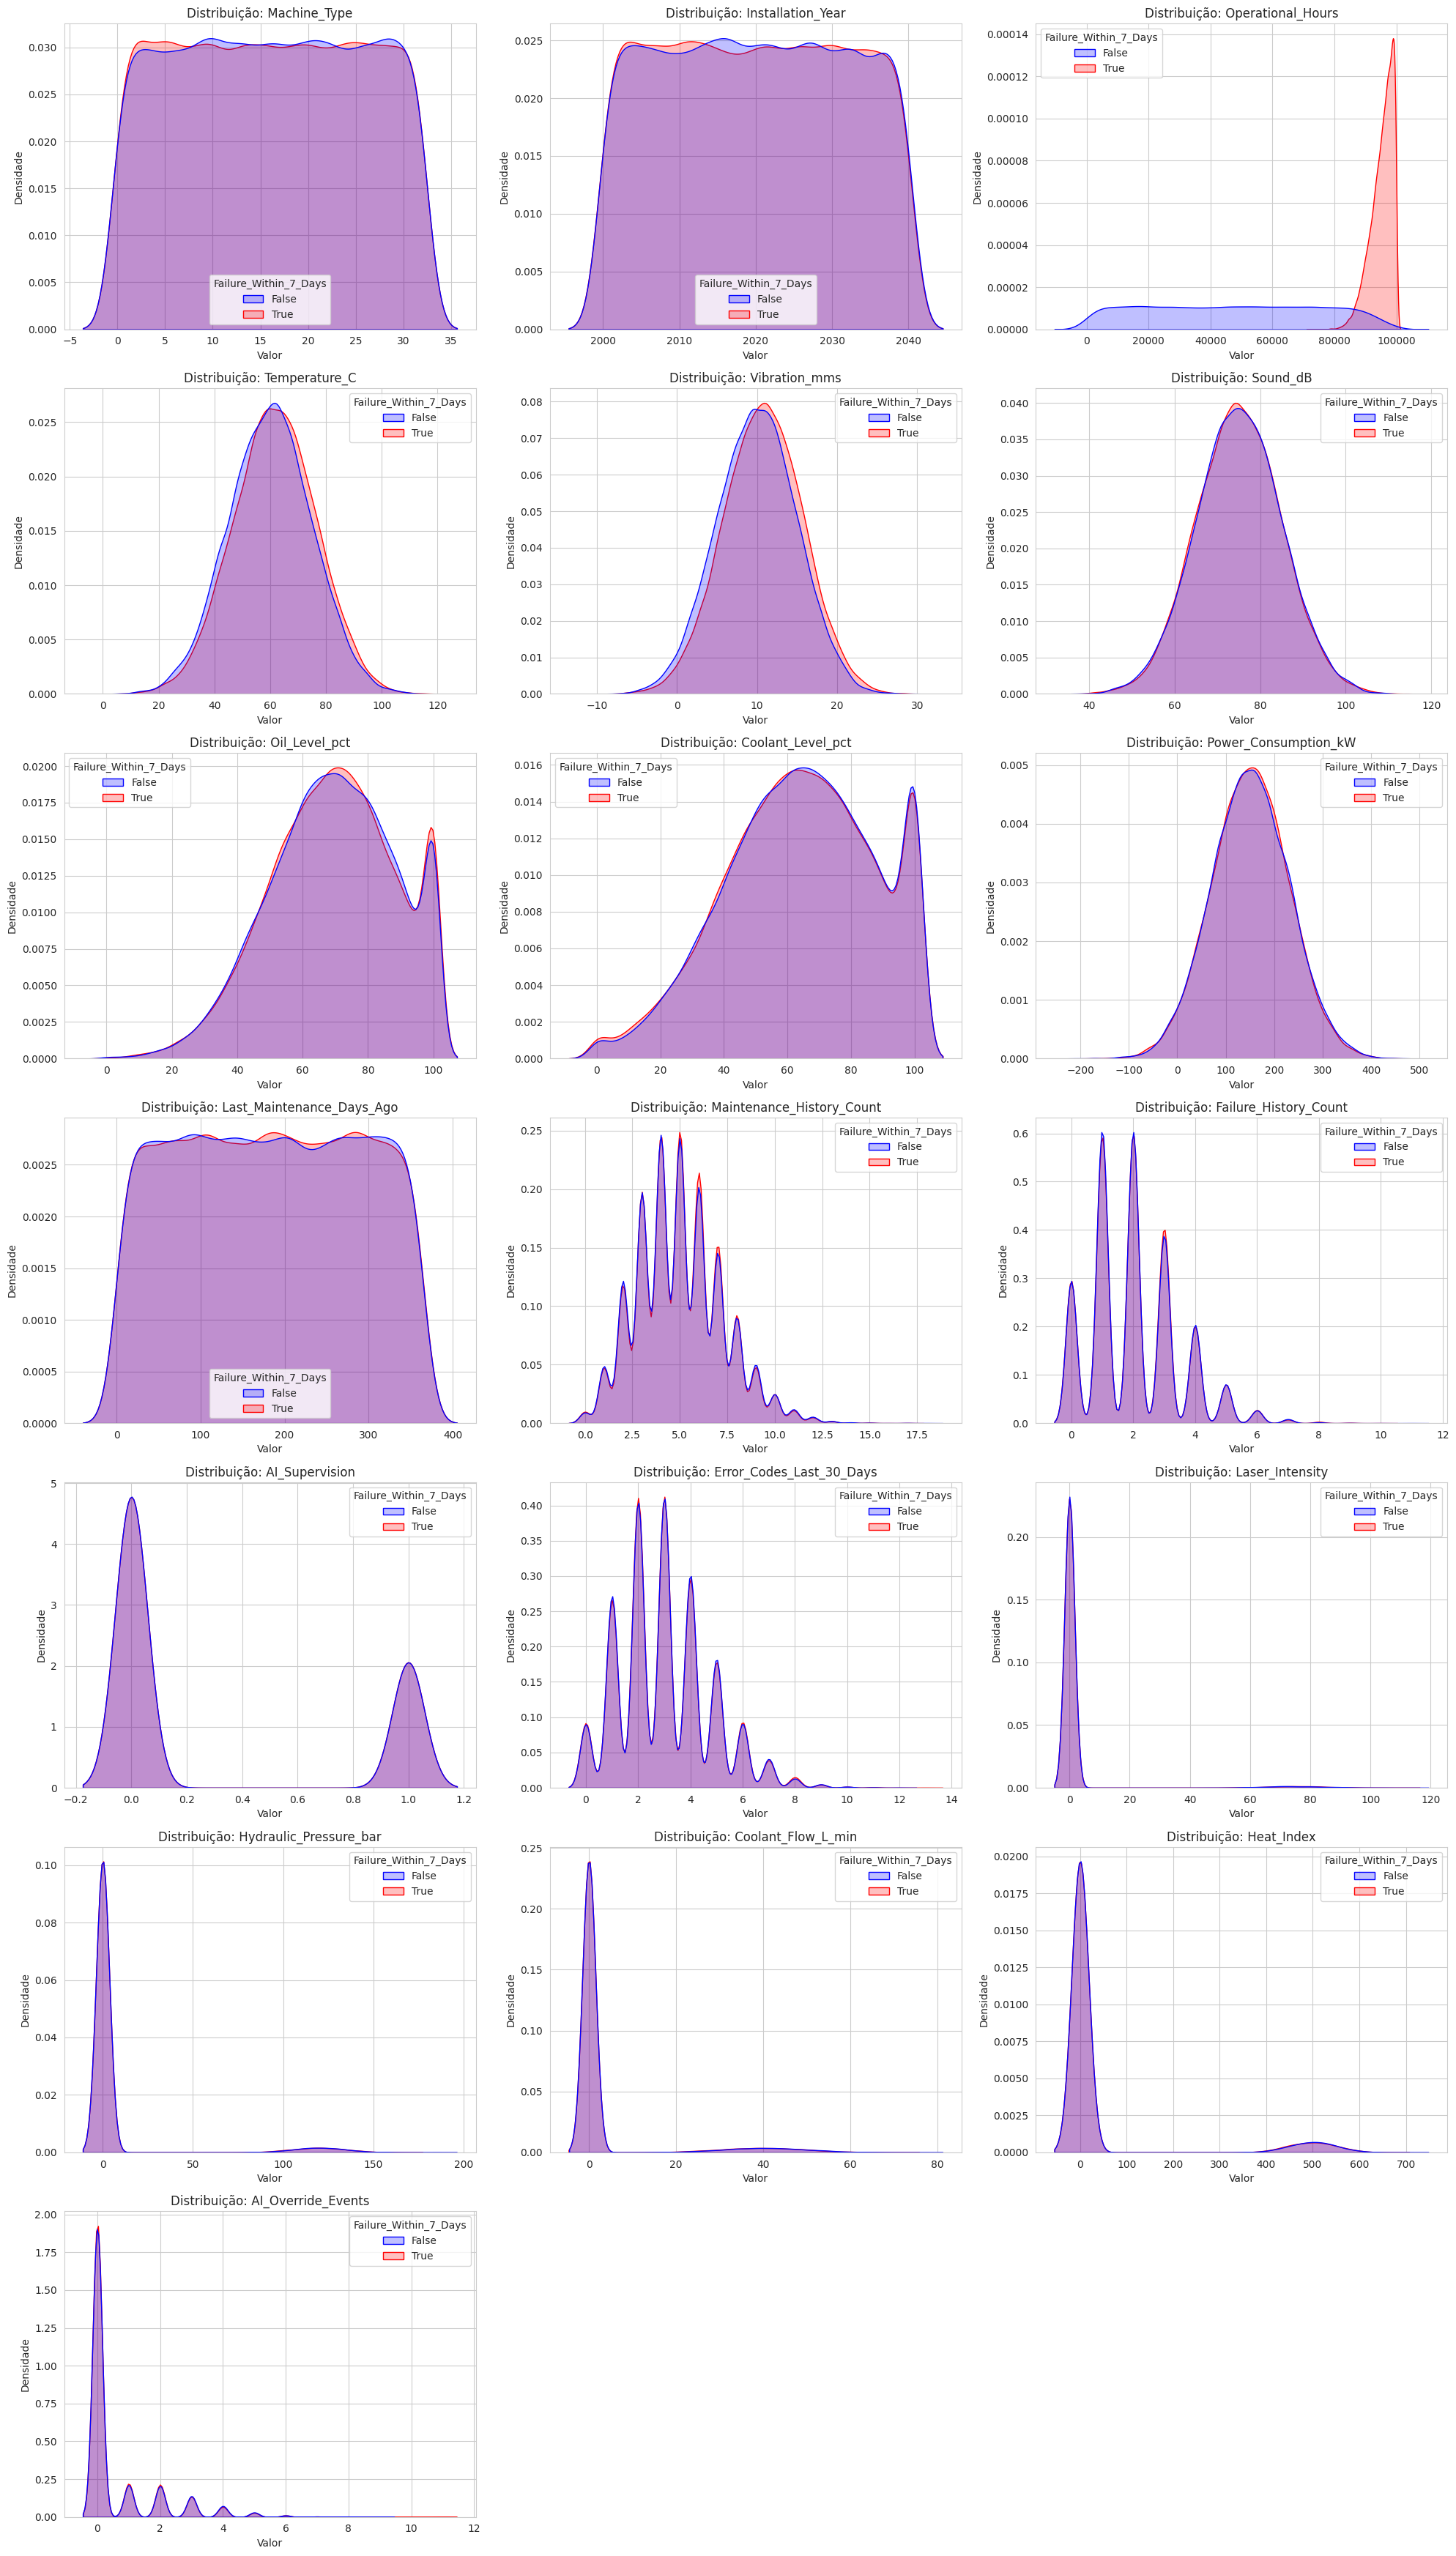

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Lista de colunas (removendo o target)
cols_to_plot = [col for col in df_balanced.columns if col != 'Failure_Within_7_Days']
n_cols = len(cols_to_plot)

# 2. Configurar a grade (calcula quantas linhas são necessárias para 3 colunas de largura)
cols_per_row = 3
n_rows = math.ceil(n_cols / cols_per_row)

# 3. Criar a figura com tamanho proporcional
plt.figure(figsize=(20, 5 * n_rows))
sns.set_style("whitegrid")

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, cols_per_row, i + 1)

    # Verificação simples para evitar erro se a coluna for constante ou tiver apenas um valor
    if df_balanced[col].nunique() > 1:
        sns.kdeplot(data=df_balanced, x=col, hue='Failure_Within_7_Days',
                    fill=True, palette={True: "red", False: "blue"},
                    common_norm=False, warn_singular=False)
    else:
        sns.histplot(data=df_balanced, x=col, hue='Failure_Within_7_Days',
                     palette={True: "red", False: "blue"}, element="step")

    plt.title(f'Distribuição: {col}', fontsize=12)
    plt.xlabel('Valor')
    plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

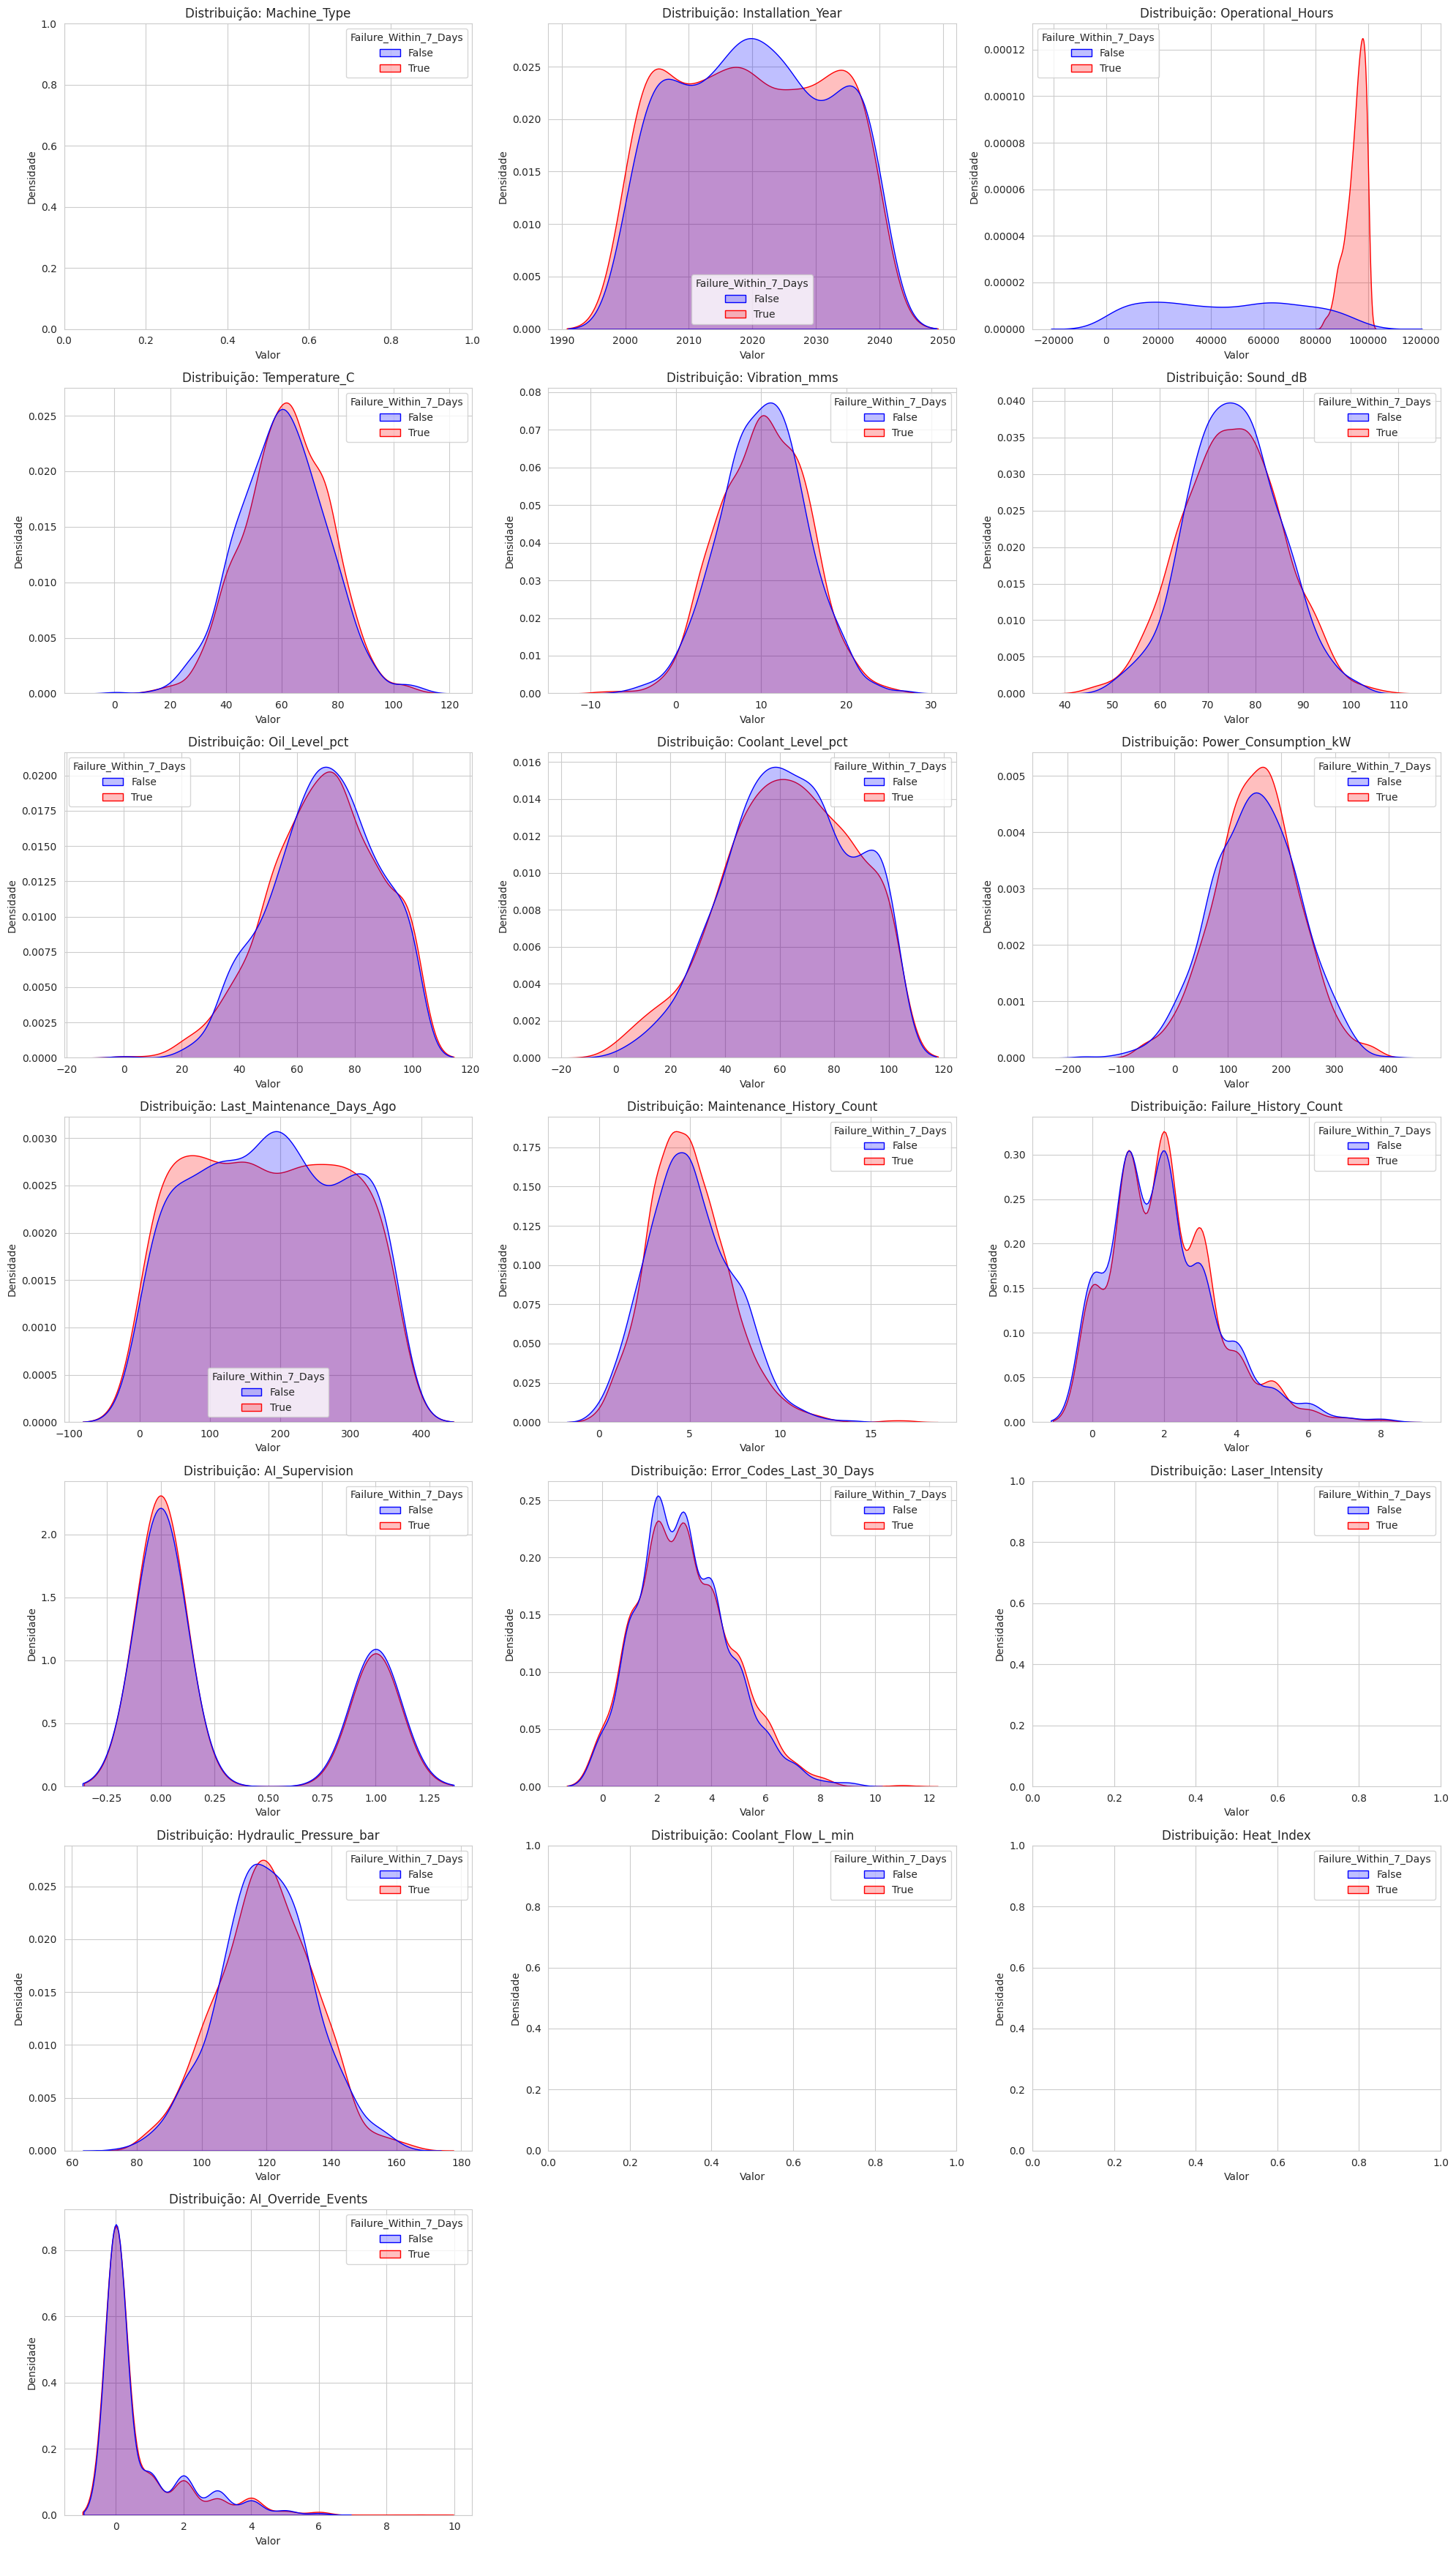

In [295]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

machine_type = 18

# 1. Lista de colunas (removendo o target)
cols_to_plot = [col for col in df_balanced.columns if col != 'Failure_Within_7_Days']
n_cols = len(cols_to_plot)

# 2. Configurar a grade (calcula quantas linhas são necessárias para 3 colunas de largura)
cols_per_row = 3
n_rows = math.ceil(n_cols / cols_per_row)

# 3. Criar a figura com tamanho proporcional
plt.figure(figsize=(20, 5 * n_rows))
sns.set_style("whitegrid")

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, cols_per_row, i + 1)

    # Verificação simples para evitar erro se a coluna for constante ou tiver apenas um valor
    if df_balanced[col].nunique() > 1:
        sns.kdeplot(data=df_balanced[df_balanced['Machine_Type'] == machine_type], x=col, hue='Failure_Within_7_Days',
                    fill=True, palette={True: "red", False: "blue"},
                    common_norm=False, warn_singular=False)
    else:
        sns.histplot(data=df_balanced[df_balanced['Machine_Type'] == machine_type], x=col, hue='Failure_Within_7_Days',
                     palette={True: "red", False: "blue"}, element="step")

    plt.title(f'Distribuição: {col}', fontsize=12)
    plt.xlabel('Valor')
    plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

# AVALIAÇÃO MODELO DE IA



In [272]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder

# Importação dos 15 Modelos
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df_balanced.drop(columns=['Failure_Within_7_Days'])
y = df_balanced['Failure_Within_7_Days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================
# 5. EXECUÇÃO DOS 15 MODELOS
# =========================================================
modelos = {
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "MLP Neural Network": MLPClassifier(max_iter=500),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Linear Discriminant": LinearDiscriminantAnalysis(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Linear SVC": LinearSVC(max_iter=10000, dual=False),
    "Passive Aggressive": PassiveAggressiveClassifier()
}

resultados = []

for nome, modelo in modelos.items():
    try:
        modelo.fit(X_train, y_train)
        preds = modelo.predict(X_test)
        resultados.append({"Modelo": nome, "Acurácia": accuracy_score(y_test, preds), "F1-Score": f1_score(y_test, preds)})
        print(f"✅ {nome} concluído.")
    except Exception as e:
        print(f"❌ Erro em {nome}: {e}")

# =========================================================
# 6. RANKING E IMPORTÂNCIA DE SENSORES
# =========================================================
df_ranking = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False)
print("\n--- RANKING FINAL ---")
print(df_ranking)

# Verificando o que o vencedor (Top 1) considerou mais importante
vencedor_nome = df_ranking.iloc[0]['Modelo']
vencedor_mod = modelos[vencedor_nome]

if hasattr(vencedor_mod, 'feature_importances_'):
    importances = vencedor_mod.feature_importances_
    feat_imp = pd.DataFrame({'Sensor': X.columns, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp.head(10), x='Importancia', y='Sensor', palette='viridis')
    plt.title(f"Principais Sensores que causam Falha (Modelo: {vencedor_nome})")
    plt.show()


✅ XGBoost concluído.
✅ Random Forest concluído.
✅ Gradient Boosting concluído.
✅ Hist Gradient Boosting concluído.
✅ Extra Trees concluído.
✅ Decision Tree concluído.
✅ AdaBoost concluído.
✅ MLP Neural Network concluído.
✅ K-Nearest Neighbors concluído.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression concluído.
✅ Ridge Classifier concluído.
✅ Linear Discriminant concluído.
✅ Gaussian Naive Bayes concluído.
✅ Linear SVC concluído.
✅ Passive Aggressive concluído.

--- RANKING FINAL ---
                    Modelo  Acurácia  F1-Score
3   Hist Gradient Boosting  0.949667  0.950798
2        Gradient Boosting  0.949500  0.950684
9      Logistic Regression  0.949417  0.950404
4              Extra Trees  0.949000  0.950397
0                  XGBoost  0.949250  0.950363
12    Gaussian Naive Bayes  0.949083  0.950353
13              Linear SVC  0.948750  0.950012
1            Random Forest  0.948667  0.949796
6                 AdaBoost  0.948417  0.949679
7       MLP Neural Network  0.947667  0.948159
8      K-Nearest Neighbors  0.944583  0.945532
14      Passive Aggressive  0.925250  0.922317
5            Decision Tree  0.920333  0.919556
10        Ridge Classifier  0.879417  0.891926
11     Linear Discriminant  0.879417  0.891926


📊 RELATÓRIO DE PERFORMANCE: GAUSSIAN NAIVE BAYES
              precision    recall  f1-score   support

Saudável (0)       0.98      0.92      0.95      6029
   Falha (1)       0.92      0.98      0.95      5971

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



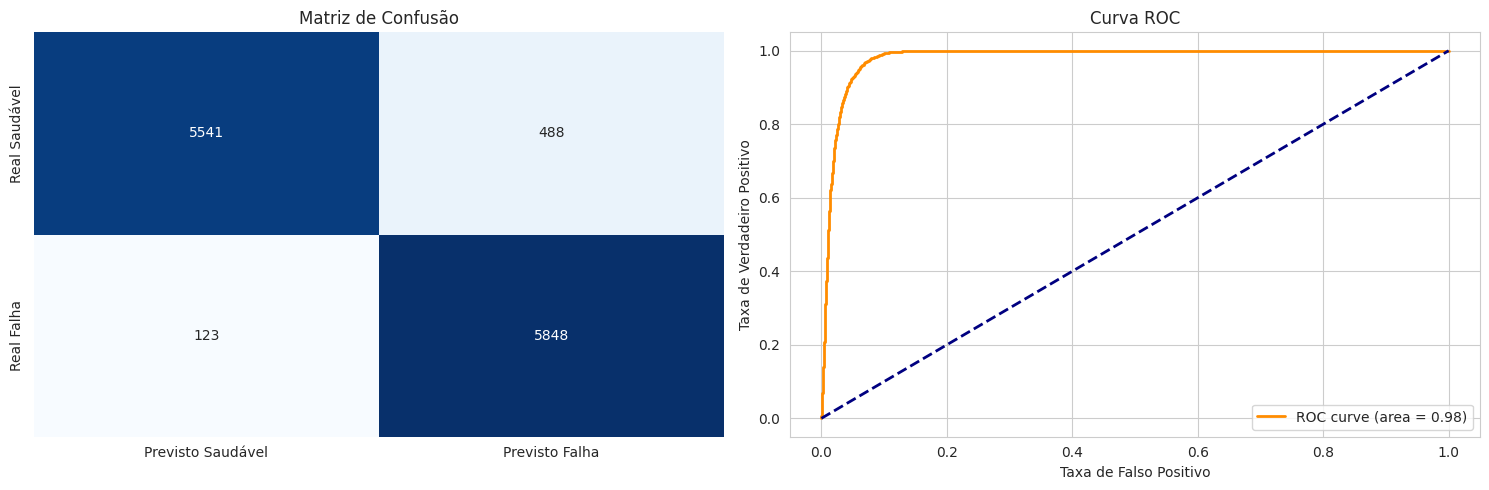

In [305]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Pegar o modelo treinado
modelo_gnb = modelos["Gaussian Naive Bayes"]
y_pred = modelo_gnb.predict(X_test)
y_proba = modelo_gnb.predict_proba(X_test)[:, 1] # Probabilidade de ser FALHA (1)

# 2. Relatório de Texto
print("="*60)
print("📊 RELATÓRIO DE PERFORMANCE: GAUSSIAN NAIVE BAYES")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Falha (1)']))

# 3. Matriz de Confusão (Visual)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto Saudável', 'Previsto Falha'],
            yticklabels=['Real Saudável', 'Real Falha'])
plt.title("Matriz de Confusão")

# 4. Curva ROC (A "Força" de Separação do Modelo)
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# MODELO DE IA PRATICANDO

In [385]:
import numpy as np
import pandas as pd

def simulador_com_diagnostico_avancado(df_referencia, modelo):
    # 1. Geração Inteligente de Dados
    novo_dado = {}

    for col in df_referencia.columns:
        min_val = df_referencia[col].min()
        max_val = df_referencia[col].max()
        unique_values = df_referencia[col].nunique()

        # Lógica para colunas Binárias (como AI_Supervision)
        if unique_values <= 2 and min_val == 0 and max_val == 1:
            novo_dado[col] = np.random.choice([0, 1])

        # Lógica para números Inteiros
        elif df_referencia[col].dtype == 'int64' or df_referencia[col].dtype == 'int32':
            novo_dado[col] = np.random.randint(min_val, max_val + 1)

        # Lógica para números Decimais (Float)
        else:
            # Gera um float aleatório entre o mínimo e o máximo real
            valor_float = np.random.uniform(min_val, max_val)
            novo_dado[col] = round(valor_float, 2)

    df_teste = pd.DataFrame([novo_dado])

    # 2. Predição de Probabilidade
    # O predict_proba retorna [prob_saudavel, prob_falha]
    prob_falha = modelo.predict_proba(df_teste)[0][1] * 100

    # 3. Diagnóstico de Causa Raiz (Cálculo de Proximidade Estatística)
    # Pegamos as médias aprendidas pelo modelo para o estado de FALHA (Classe 1)
    medias_falha = modelo.theta_[1]

    scores_criticos = []
    for i, col in enumerate(df_referencia.columns):
        valor_atual = novo_dado[col]
        # Distância absoluta: quanto menor, mais 'parecido' com uma falha histórica
        distancia = abs(valor_atual - medias_falha[i])
        scores_criticos.append((col, valor_atual, distancia))

    # Ordena para pegar os 3 sensores que mais "encaixam" no padrão de falha
    diagnostico = sorted(scores_criticos, key=lambda x: x[2])[:3]

    # 4. Exibição do Relatório Formatado
    print("\n" + "═"*60)
    print(f" 🛠️  SISTEMA DE MONITORAMENTO: {vencedor_nome.upper()} ".center(60, "═"))
    print("═"*60)

    if prob_falha > 90:
        alerta, acao = "🔴 ALERTA VERMELHO", "PARADA IMEDIATA PARA MANUTENÇÃO CORRETIVA."
    elif 51 <= prob_falha <= 90:
        alerta, acao = "🟡 ESTADO DE ATENÇÃO", "AGENDAR INSPEÇÃO TÉCNICA EM 24 HORAS."
    elif 45 <= prob_falha < 51:
        alerta, acao = "⚪ IA EM DÚVIDA", "RECALIBRAR SENSORES E REPETIR TESTE."
    else:
        alerta, acao = "🟢 OPERAÇÃO NORMAL", "NENHUMA INTERVENÇÃO NECESSÁRIA."

    print(f"STATUS: {alerta}")
    print(f"CONFIANÇA DE FALHA: {prob_falha:.2f}%")
    print(f"RECOMENDAÇÃO: {acao}")

    if prob_falha > 45:
        print("\n" + "🔍 DIAGNÓSTICO DE CAUSA RAIZ ".center(60, "-"))
        for col, val, dist in diagnostico:
            print(f" -> {col.ljust(25)}: {val} (Valor crítico para o histórico)")

    print("\n" + "📋 LEITURA COMPLETA DOS SENSORES ".center(60, "-"))
    for i, (col, val) in enumerate(novo_dado.items()):
        print(f"{col.ljust(25)}: {str(val).ljust(8)}", end=" | " if (i+1)%2 != 0 else "\n")
    print("\n" + "═"*60)

# Executar o teste
# X é o seu dataframe de sensores usado no treino
simulador_com_diagnostico_avancado(X, modelos["Gaussian Naive Bayes"])


════════════════════════════════════════════════════════════
═══ 🛠️  SISTEMA DE MONITORAMENTO: HIST GRADIENT BOOSTING ═══
════════════════════════════════════════════════════════════
STATUS: 🔴 ALERTA VERMELHO
CONFIANÇA DE FALHA: 96.89%
RECOMENDAÇÃO: PARADA IMEDIATA PARA MANUTENÇÃO CORRETIVA.

----------------🔍 DIAGNÓSTICO DE CAUSA RAIZ ----------------
 -> AI_Supervision           : 0 (Valor crítico para o histórico)
 -> AI_Override_Events       : 1 (Valor crítico para o histórico)
 -> Failure_History_Count    : 4 (Valor crítico para o histórico)

--------------📋 LEITURA COMPLETA DOS SENSORES --------------
Machine_Type             : 24       | Installation_Year        : 2016    
Operational_Hours        : 94809    | Temperature_C            : 92.2    
Vibration_mms            : 3.53     | Sound_dB                 : 40.71   
Oil_Level_pct            : 6.04     | Coolant_Level_pct        : 47.46   
Power_Consumption_kW     : 304.66   | Last_Maintenance_Days_Ago: 71      
Maintenance_Hi

# BAIXANDO MODELO

In [361]:
import joblib

# Definindo o nome do arquivo
nome_arquivo = 'modelo_manutencao_gnb.joblib'

# Salvando o modelo treinado e as colunas (para o programador saber a ordem)
dados_para_exportar = {
    'modelo': modelos["Gaussian Naive Bayes"],
    'colunas': X.columns.tolist()
}

joblib.dump(dados_para_exportar, nome_arquivo)

print(f"✅ Sucesso! O arquivo '{nome_arquivo}' foi gerado.")
print("Envie este arquivo para o desenvolvedor do software.")

✅ Sucesso! O arquivo 'modelo_manutencao_gnb.joblib' foi gerado.
Envie este arquivo para o desenvolvedor do software.


In [386]:
import joblib
import pandas as pd

# 1. CARREGAR O MODELO EXPORTADO
# Certifique-se que o arquivo .joblib está na mesma pasta
pacote = joblib.load('modelo_manutencao_gnb.joblib')
ia = pacote['modelo']
colunas_treinadas = pacote['colunas']

def sistema_monitoramento_manual(valores_sensores):
    # Converte para DataFrame respeitando a ordem das colunas do treino
    df_input = pd.DataFrame([valores_sensores])[colunas_treinadas]

    # Cálculo da Probabilidade de Falha
    prob_falha = ia.predict_proba(df_input)[0][1] * 100

    # Lógica de Alerta (Semáforo)
    if prob_falha > 90:
        status, alerta = "🔴 ALERTA VERMELHO", "PARADA IMEDIATA PARA MANUTENÇÃO."
    elif 51 <= prob_falha <= 90:
        status, alerta = "🟡 ESTADO DE ATENÇÃO", "AGENDAR INSPEÇÃO TÉCNICA."
    elif 45 <= prob_falha < 51:
        status, alerta = "⚪ IA EM DÚVIDA", "RECALIBRAR SENSORES."
    else:
        status, alerta = "🟢 OPERAÇÃO NORMAL", "TUDO SOB CONTROLE."

    # --- RELATÓRIO FORMATADO ---
    print("\n" + "═"*60)
    print(" 🛠️  DIAGNÓSTICO DO SISTEMA ".center(60, "═"))
    print("═"*60)
    print(f"STATUS: {status}")
    print(f"CONFIANÇA DE FALHA: {prob_falha:.2f}%")
    print(f"RECOMENDAÇÃO: {alerta}")

    print("\n" + "--------------📋 LEITURA COMPLETA DOS SENSORES --------------")

    # Exibe os sensores no formato de duas colunas que você pediu
    itens = list(valores_sensores.items())
    for i in range(0, len(itens), 2):
        col1, val1 = itens[i]
        if i + 1 < len(itens):
            col2, val2 = itens[i+1]
            print(f"{col1.ljust(25)}: {str(val1).ljust(8)} | {col2.ljust(25)}: {str(val2).ljust(8)}")
        else:
            print(f"{col1.ljust(25)}: {str(val1).ljust(8)} |")

    print("═"*60)

# =========================================================
# VALORES MANUAIS PARA TESTE
# =========================================================
meus_sensores = {
    'Machine_Type': 24,
    'Installation_Year': 2016,
    'Operational_Hours': 94809,
    'Temperature_C': 92.2,
    'Vibration_mms': 3.53,
    'Sound_dB': 40.71,
    'Oil_Level_pct': 6.04,
    'Coolant_Level_pct': 47.46,
    'Power_Consumption_kW': 304.66,
    'Last_Maintenance_Days_Ago': 71,
    'Maintenance_History_Count': 9,
    'Failure_History_Count': 4,
    'AI_Supervision': 0,
    'Error_Codes_Last_30_Days': 11,
    'Laser_Intensity': 31.3,
    'Hydraulic_Pressure_bar': 113.88,
    'Coolant_Flow_L_min': 40.64,
    'Heat_Index': 78.57,
    'AI_Override_Events': 1
}

# Executar a análise
sistema_monitoramento_manual(meus_sensores)


════════════════════════════════════════════════════════════
════════════════ 🛠️  DIAGNÓSTICO DO SISTEMA ════════════════
════════════════════════════════════════════════════════════
STATUS: 🔴 ALERTA VERMELHO
CONFIANÇA DE FALHA: 96.89%
RECOMENDAÇÃO: PARADA IMEDIATA PARA MANUTENÇÃO.

--------------📋 LEITURA COMPLETA DOS SENSORES --------------
Machine_Type             : 24       | Installation_Year        : 2016    
Operational_Hours        : 94809    | Temperature_C            : 92.2    
Vibration_mms            : 3.53     | Sound_dB                 : 40.71   
Oil_Level_pct            : 6.04     | Coolant_Level_pct        : 47.46   
Power_Consumption_kW     : 304.66   | Last_Maintenance_Days_Ago: 71      
Maintenance_History_Count: 9        | Failure_History_Count    : 4       
AI_Supervision           : 0        | Error_Codes_Last_30_Days : 11      
Laser_Intensity          : 31.3     | Hydraulic_Pressure_bar   : 113.88  
Coolant_Flow_L_min       : 40.64    | Heat_Index              